<div class="alert alert-block alert-info"> 
    <center><h1 "> Tarea 5: Cálculo Científico I - MAT2605</h1> </center>
</div>
    <!-- <b></b>     -->
    <h4 style="color:#173F8A;;text-align:right;"> Profesor: Manuel A. Sánchez<br> Ayudantes: Diego Vera, Tomás Malfetano <br></h4>

<!-- 
<div class="alert alert-block alert-success"> Use green boxes sparingly, and only for some specific purpose that the other boxes can't cover. For example, if you have a lot of related content to link to, maybe you decide to use green boxes for related links from each section of a notebook. </div>

<div class="alert alert-block alert-warning"> Use yellow boxes for examples that are not inside code cells, or use for mathematical formulas if needed. </div>

<div class="alert alert-block alert-danger"> In general, just avoid the red boxes. </div>

############# Markdown parser in Sphinx ##################

<div class="admonition note"> <p class="admonition-title">Note</p> <p>You should note that the title will be automatically capitalized.</p> </div>

<div class="admonition danger"> <p class="admonition-title">Don't try this at home</p> <p>...</p> </div>
 -->
<!-- <div class="admonition important"> <p>This is an admonition box without a title.</p> </div> -->

<div class="alert alert-block alert-success"> <b> Nombre de estudiante: </b> Rafael Ignacio Lorca Muñoz</div>


In [2]:
import numpy as np
import matplotlib.pyplot as plt

<div class="alert alert-block alert-info"> <b> Problema 1. Ciclo adenina </b> </div>

Considere el siguiente sistema de ecuaciones diferenciales ordinarias para las concentraciones de $atp$, $amp$ y $adp$
\begin{align*}
\frac{d[atp]}{dt} & =  -v_{ACS} - v_{AK} + v_{PK} \\
\frac{d[amp]}{dt} & =   v_{ACS} - v_{AK} \\
\frac{d[adp]}{dt} & =            2v_{AK} - v_{PK}
\end{align*}
donde
\begin{align}
v_{ACS} & = \frac{2.3 [atp]}{700 + [atp]} \\
v_{AK}  & =  \frac{170 [atp] [amp]}{71000 + 25[amp]+110[atp]+[atp][amp]}\\
v_{PK}  & =  \frac{65[adp]}{260 + [adp]}
\end{align}

Use el método de Newton-Raphson para aproximar un estado de equilibrio del sistema. (tolerancia $10^{-10}$)


<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

Tenemos que definir una matriz jacobiana para el problema y el vector que queremos iterar. En el problema se busca el estado estacionario, esto quiere decir que las derivadas de las concentraciones en el tiempo sean $=0$, definimos entonces:

$$\mathbf{x} = 
\begin{bmatrix} 
 [\texttt{atp}] \\  [\text{amp}] \\ [\text{adp}]  
\end{bmatrix} 
,\quad \mathbf{F}(\mathbf{x}) = \begin{bmatrix} f_1\\f_2\\f_3 \end{bmatrix} = \begin{bmatrix} 
 -v_{ACS} - v_{AK} + v_{PK} \\  v_{ACS} - v_{AK} \\ 2v_{AK} - v_{PK}  
\end{bmatrix} $$

Resolvemos $F(x) = 0$ con Newton:
$$
x^{(k+1)} = x^{(k)}-J(x^{(k)})^{-1}F(x^{(k)})
$$

In [53]:
def sistema(x):
    atp, amp, adp = x
    
    # Velocidades de reacción
    v_ACS = (2.3 * atp) / (700 + atp)
    v_AK = (170 * atp * amp) / (71000 + 25*amp + 110*atp + atp*amp)
    v_PK = (65 * adp) / (260 + adp)
    
    # Sistema F(x) = 0
    f1 = -v_ACS - v_AK + v_PK
    f2 = v_ACS - v_AK
    f3 = 2*v_AK - v_PK
    
    return np.array([f1, f2, f3])

def jacobiano(x):
    atp, amp, adp = x

    den_ACS = (700 + atp)**2
    den_AK = (71000 + 25*amp + 110*atp + atp*amp)**2
    den_PK = (260 + adp)**2

    # Derivadas
    # ACS solo depende de ATP
    d_ACS_aATP = 1610 / den_ACS

    # AK:
    numerador_AK = 170 * atp * amp
    denominador_AK = 71000 + 25*amp + 110*atp + atp*amp
    
    d_AK_dATP = (170 * amp * denominador_AK - numerador_AK * (110 + amp)) / den_AK
    d_AK_dAMP = (170 * atp * denominador_AK - numerador_AK * (25 + atp)) / den_AK
    
    # PK solo depende de ADP
    d_PK_dADP = 16900 / den_PK
    
    J = np.zeros((3, 3))
    
    # f1/datp , f1/damp , f1/dadp: f1 = (-vacs - vak + vpk)
    J[0, 0] = -d_ACS_aATP - d_AK_dATP
    J[0, 1] = -d_AK_dAMP  
    J[0, 2] = d_PK_dADP
    
    # f2/datp , f2/damp , f2/dadp: f2 = (vacs - vak)
    J[1, 0] = d_ACS_aATP - d_AK_dATP
    J[1, 1] = -d_AK_dAMP
    J[1, 2] = 0
    
    # f3/datp , f3/damp , f3/dadp: f3 = (2vak - vpk)
    J[2, 0] = 2 * d_AK_dATP
    J[2, 1] = 2 * d_AK_dAMP
    J[2, 2] = -d_PK_dADP
    
    return J

def Newton_Raphson(x0, max_iter = 1000, tol = 10e-10):
    x = x0.copy()

    for i in range(max_iter):
        F = sistema(x)
        J = jacobiano(x)

        if np.linalg.norm(F) < tol:
            print(f"Convergió en {i+1} iteraciones")
            return x
        
        # Iteración N-R
        dx = np.linalg.solve(J, -F)
        x = x + dx
    
    print('MAXIMO DE ITERACIONES ALCANZADO')
    return x

# Empezamos con valores cualquiera de concentraciones:
x0 = np.array([50.0, 20.0, 40.0])

equilibrio = Newton_Raphson(x0)
print(f"\nEstado de equilibrio:")
print(f"[ATP] = {equilibrio[0]}")
print(f"[AMP] = {equilibrio[1]}")
print(f"[ADP] = {equilibrio[2]}")

LinAlgError: Singular matrix

<div class="alert alert-block alert-info"> <b> Problema 2. Interpolación </b> </div>

Considere la función de Runge
$$
\begin{equation*}
f(x) = \frac{1}{ 1+25 x^2}
\end{equation*}
$$

- Calcule el polinomio de interpolaci\'on utilizando $n$-puntos equiespaciado en el intervalo [- 1,1], para n = 2, 4, 8, 16, 32, 64. Grafique el interpolador y la función f y comente sus observaciones.
- Calcule el polinomio de interpolaci\'on utilizando los $n$-puntos de Tchebychev en el intervalo [-1,1], para n = 2, 4, 8, 16, 32, 64. Grafique el interpolador y la función f y comente sus observaciones.

Programe cada paso de los algoritmos sin utilizar funciones de librerías.

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

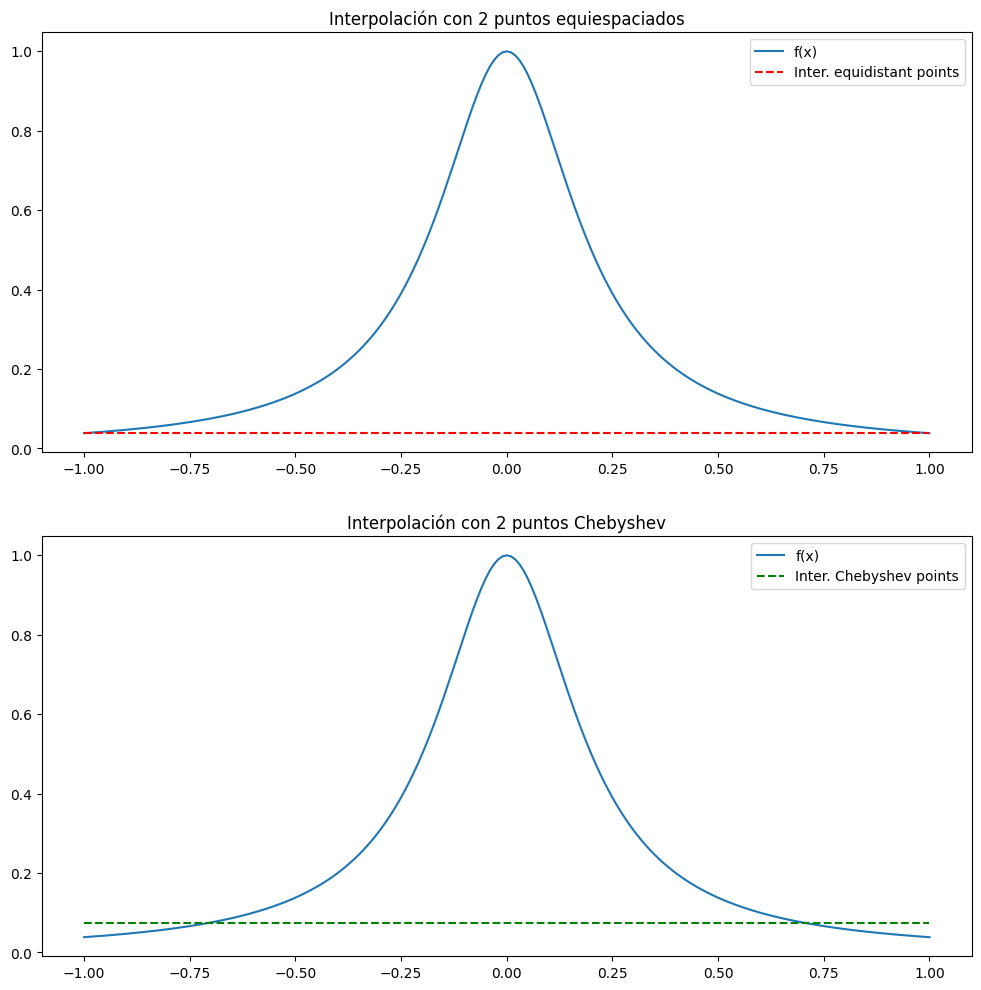

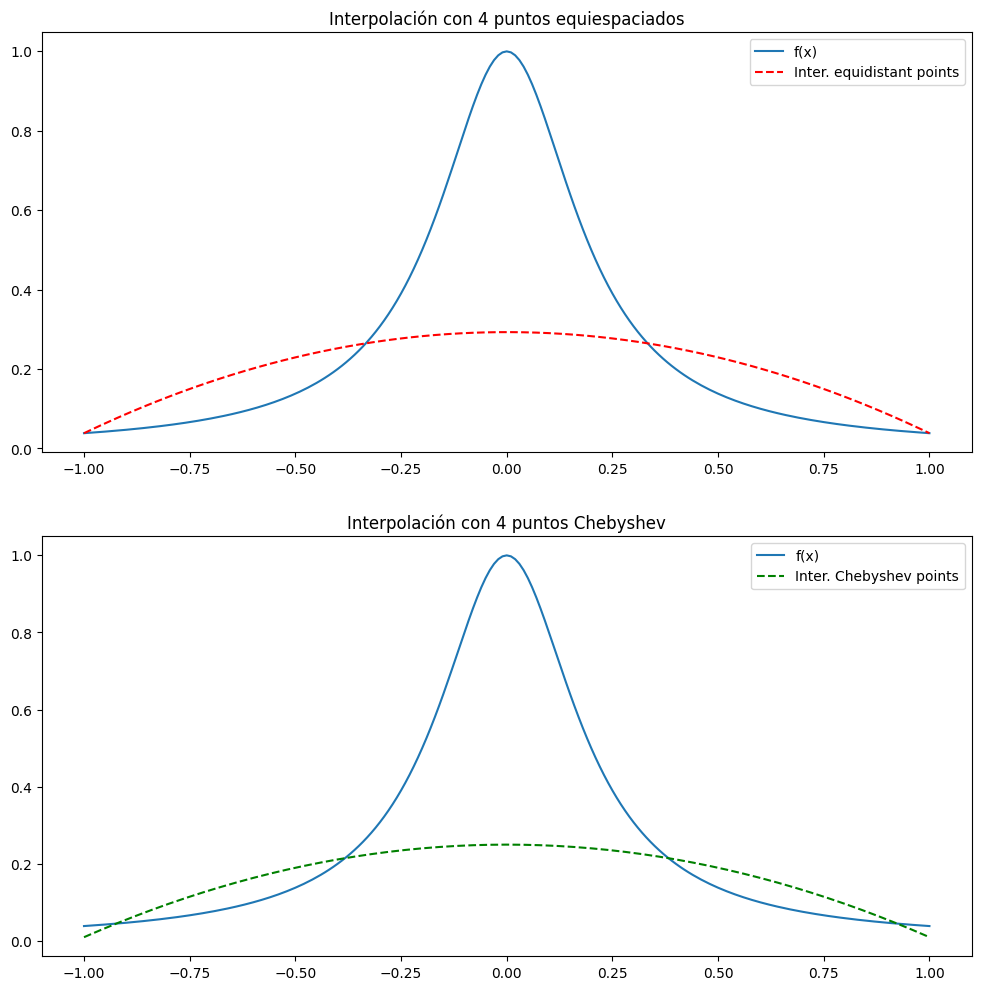

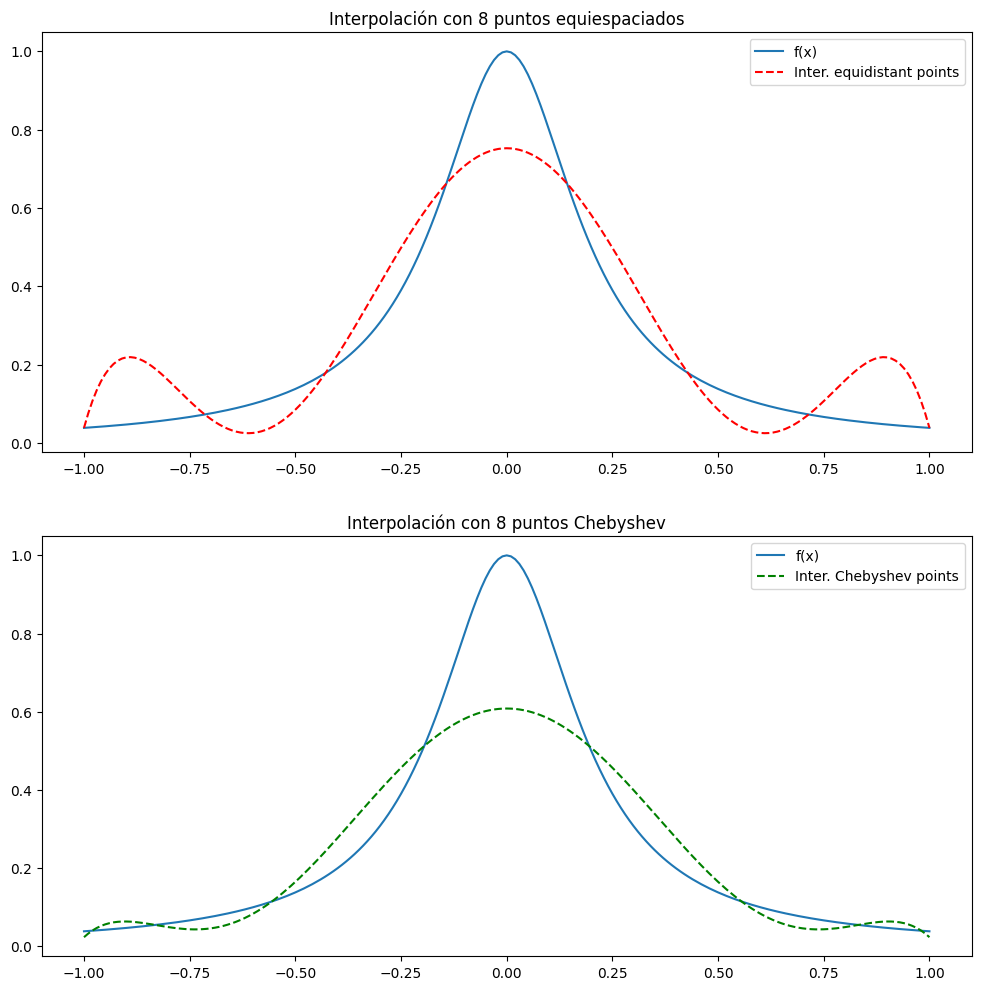

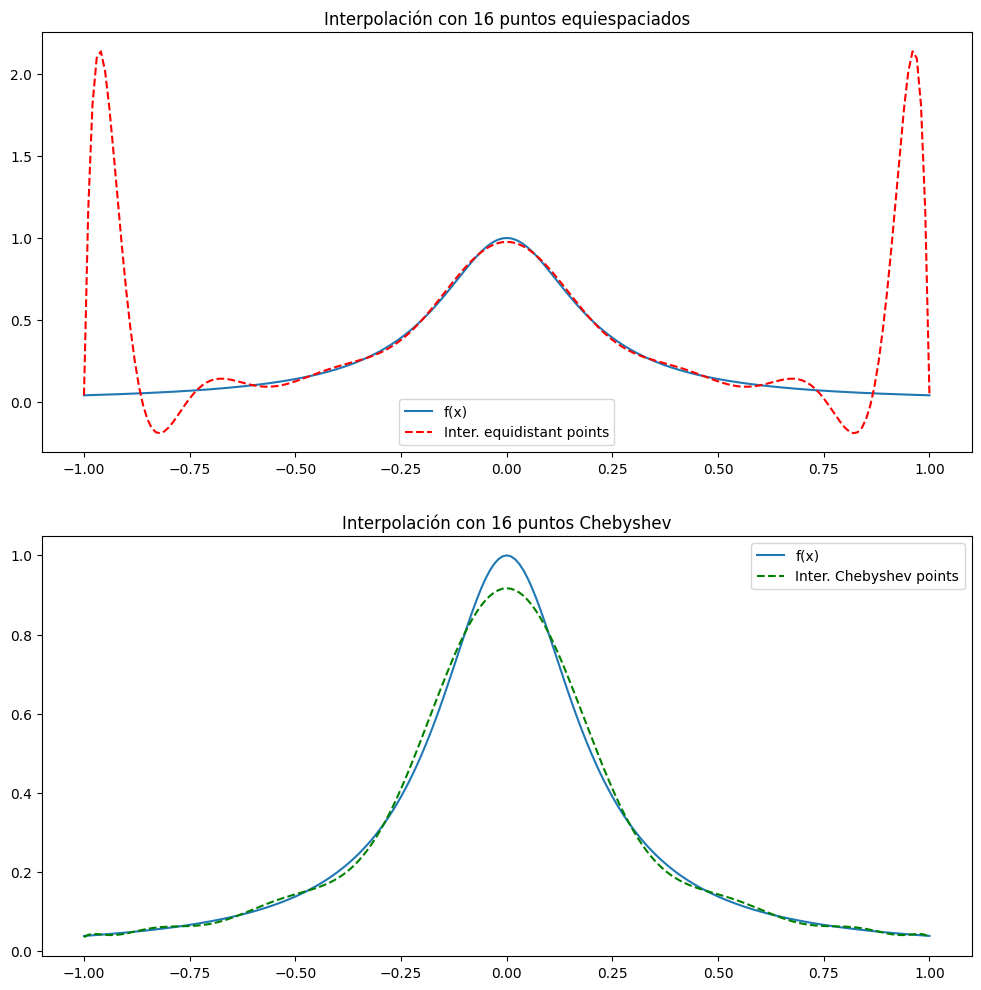

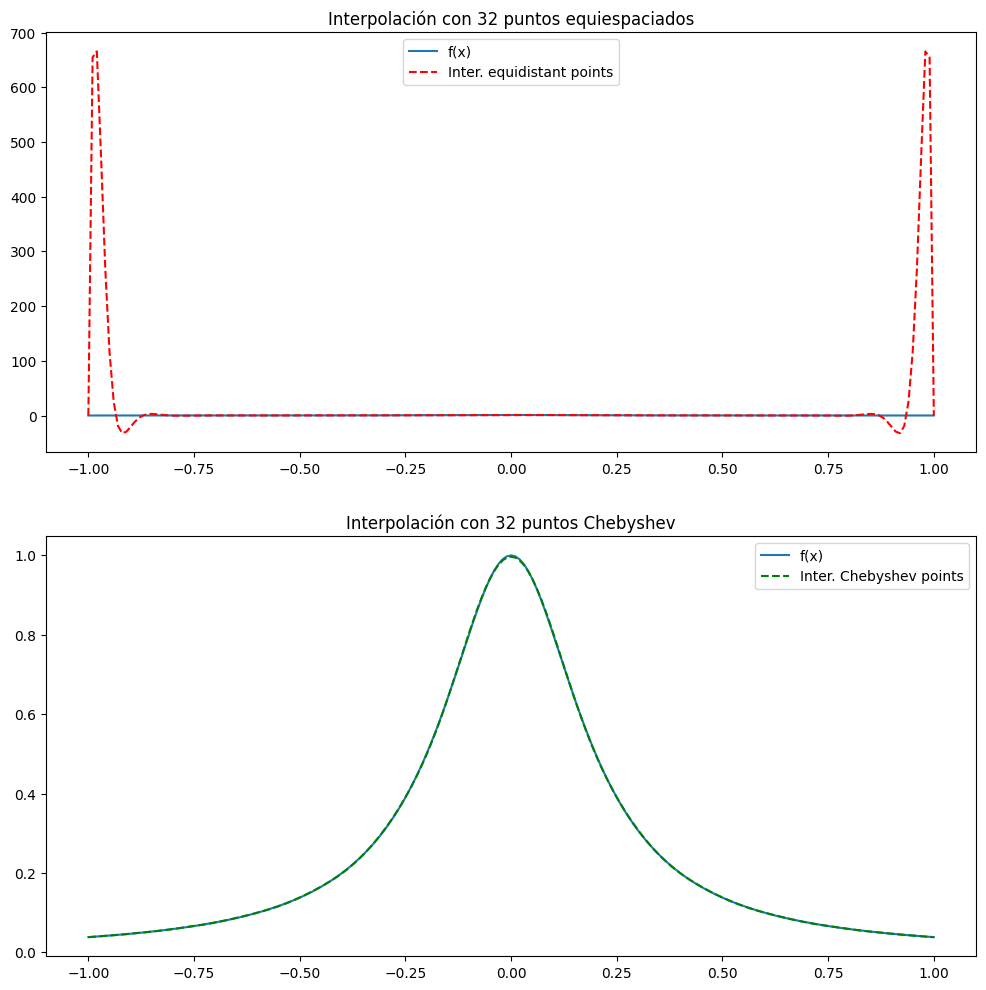

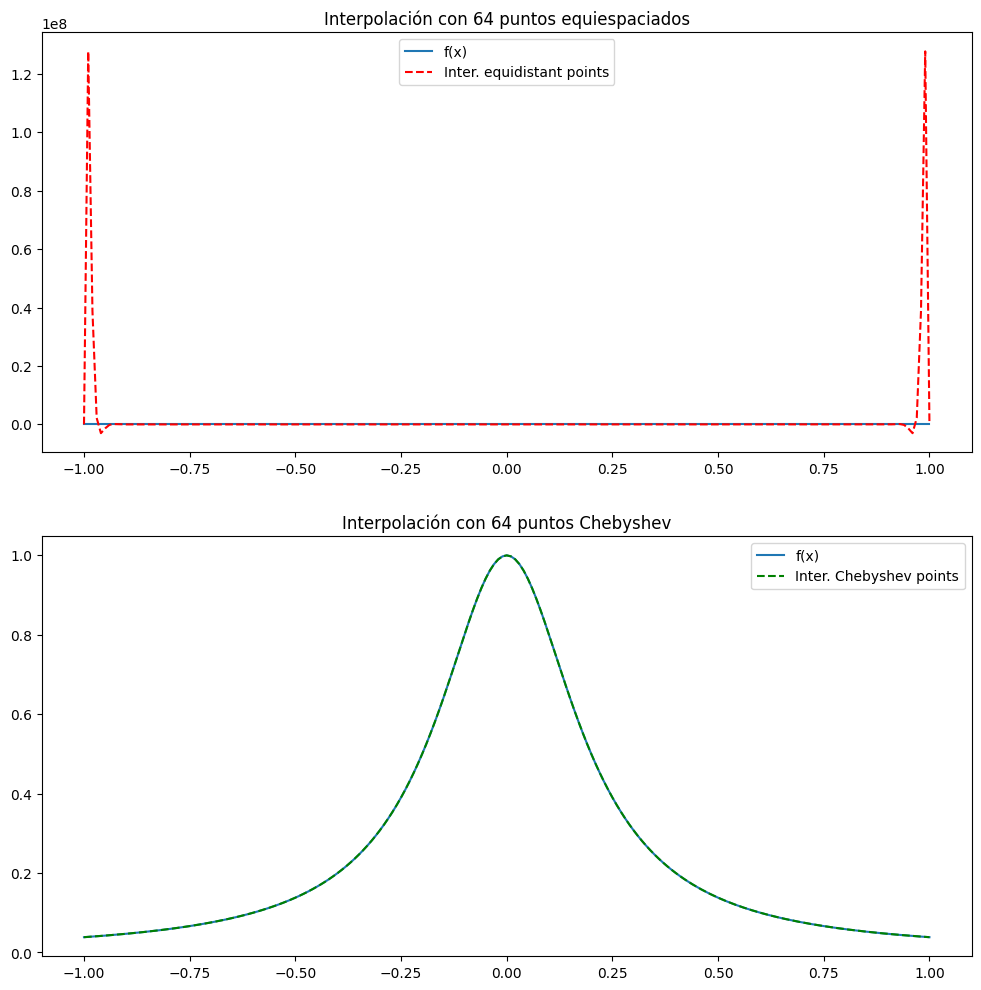

In [54]:
def runge(x):
    return 1 / (1 + 25*x**2)

def interpolante(f, x_nodos, x_eval):
    n = len(x_nodos)
    P = np.zeros(len(x_eval))

    for k in range(n):
        L = 1
        for i in range(n):
            if i!=k:
                L *= (x_eval - x_nodos[i]) / (x_nodos[k] - x_nodos[i])
        P += f(x_nodos[k]) * L
    
    return P

def generar_puntos(a, b, n):
    return np.array([a +i*(b-a)/(n-1) for i in range(n)])

enes = [2, 4, 8, 16, 32, 64]
x_plot = generar_puntos(-1, 1, 201)

# Generamos los polinomios interpolantes:
for n in enes:
    nodos_eq = generar_puntos(-1, 1, n)
    nodos_ch = np.cos((np.arange(0, n) + 1/2)*np.pi/n)

    poly_eq = interpolante(runge, nodos_eq, x_plot)
    poly_ch = interpolante(runge, nodos_ch, x_plot)

    # Plot puntos interpolados
    fig, axs = plt.subplots(2, 1, figsize=(12,12))
    axs[0].plot(x_plot, runge(x_plot), label='f(x) = 1/(1+25x²)')
    axs[0].plot(x_plot, poly_eq, 'r--', label=f'Interpolante (n={n})')
    axs[0].legend(['f(x)','Inter. equidistant points'])
    axs[0].set_title(f'Interpolación con {n} puntos equiespaciados')

    # Plot con Chebyshev
    axs[1].plot(x_plot, runge(x_plot), label='f(x) = 1/(1+25x²)')
    axs[1].plot(x_plot, poly_ch, 'g--', label=f'Interpolante (n={n})')
    axs[1].legend(['f(x)','Inter. Chebyshev points'])
    axs[1].set_title(f'Interpolación con {n} puntos Chebyshev')
    plt.show()

##### Observaciones:
- Más que claro que interpolar una función con polinomios de Chebyshev es mucho mejor que con Lagrange (puntos equiespaciados). Esto se puede ver desde $n=16$, donde ya hay una diferencia considerable.

- Es cierto que para n menores a 16 no se pueden apreciar grandes diferencias en los polinomios obtenidos, desde ese n en adelante podemos observar como los polinomios explotan en los límites de la función (cerca de -1 y 1) en el caso de los puntos equiespaciados. Para n muy grande ya no se puede apreciar la función de Runge por lo mala que es la interpolación.
  
- Para funciones como la de Runge, es mejor interpolar con nodos de Chebyshev.


<div class="alert alert-block alert-info"> <b> Problema 3. Interpolación, forma de Newton </b> </div> 

Pruebe que el polinomio que interpola una función $f$ en los puntos distintos $x_0, x_1, ...,x_n$ esta dado por la fórmula
$$
p(x) = f(x_0) + f[x_0,x_1](x-x_0) + f[x_0,x_1,x_2](x-x_0)(x-x_1) +...+f[x_0,...,x_n](x-x_0)...(x-x_{n-1})
$$
<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

La idea de interpolar un punto es que $p(x^*) = f(x^*)$. Luego, por la forma de Newton veamos que ocurre para cada valor de puntos $x_n$. Construimos el polinomio inductivamente:

- Caso $n=0$: 
$$ 
P_0(x_0) = f(x_0)
$$
- Caso $n=1$:  
$$
P_1(x) = f(x_0) + f[x_0,x_1](x-x_0)
$$
Evaluando en $x=x_0$:
$$
P_1(x_0) = f(x_0),
$$
y en $x=x_1$:
$$
P_1(x_1) = f(x_0) + f[x_0,x_1](x_1-x_0)
= f(x_0) + \frac{f(x_1)-f(x_0)}{x_1-x_0}(x_1-x_0)
= f(x_1).
$$
Por lo tanto, $P_1$ interpola $f$ en $x_0$ y $x_1$.

- Hipótesis inductiva:  

Supongamos que el polinomio de grado $k-1$ es tal que:
$$
P_{k-1}(x) = f(x_0) + f[x_0,x_1](x-x_0) + \dots + f[x_0,\dots,x_{k-1}](x-x_0)\dots(x-x_{k-2})
$$
Interpola $f$ en los puntos $x_0,\dots,x_{k-1}$, esto es equivalente a decir que, $P_{k-1}(x_i)=f(x_i)$ para todo $i\leq k-1$.

- Paso inductivo:

Probemos para $k = n$ que se cumple la hipótesis:
$$
p(x) = f(x_0) + f[x_0,x_1](x - x_0) +  \dots + f[x_0,x_1,x_2, \dots, x_{k-1},x_k](x - x_0)\dots(x - x_{k-1})
$$

Notemos que: $P_0(x) = f(x_0)$ , $P_1(x) = f(x_0) + f[x_0,x_1](x - x_0)$ , ... , $ P_{k-1}(x) =  f(x_0) + f[x_0,x_1](x - x_0) +  \dots + f[x_0,x_1,x_2, \dots, x_{k-1}](x - x_0)\dots(x - x_{k-2})$. Luego el polinomio anterior se puede reescribir de la forma:
$$
p(x) = P_{k-1}(x) + f[x_0,x_1,x_2, \dots, x_{k-1},x_k](x - x_0)\cdots(x - x_{k-1})
$$

Para $i = 0,\dots,k-1$: $p(x_i) = P_{k-1}(x_i) + 0 = f(x_i)$ por hipótesis inductiva. Ahora, para $i = k$, las diferencias divididas nos quedan de la forma:
$$
f[x_0,\dots,x_k] = \frac{f(x_k) -P_{k-1}(x_k)}{(x_k-x_0)\cdots(x_k-x_{k-1})}
$$
Entonces:
$$
p(x_k) = P_{k-1}(x_k) + \frac{f(x_k) -P_{k-1}(x_k)}{(x_k-x_0)\cdots(x_k-x_{k-1})} (x_k - x_0)\cdots(x_k - x_{k-1})
$$
$$
p(x_k) = P_{k-1}(x_k) + f(x_k) -P_{k-1}(x_k) = f(x_k)
$$

Así, mostramos que $p(x)$ interpola $f$ en $x_0,\dots,x_k$.

<div class="alert alert-block alert-info"> <b> Problema 4. </b> </div>

- Calcular el grado minimo que debe tener un polinimio de grado menor o igual a n que interpola en los ceros del polinomio de Tchebychev $T_{n+1}$ a la funcion $f(x) = e^{2x}$, $x\in[-1,1]$, para que el error sea menor que $10^{-2}$ y luego $10^{-4}$.
- Calcular el grado minimo que debe tener un polinimio de grado menor o igual a n que interpola en los ceros del polinomio de Tchebychev $T_{n+1}$ a la funcion $f(x) = e^{x}$, $x\in[0,4]$, para que el error sea menor que $10^{-2}$ y luego $10^{-4}$.

<div class="alert alert-block alert-success"> <b> Solución. </b> </div>

Por teorema sabemos que si tenemos una función $f\in C^{n+1}[-1,1]$. Si $p_n\in P_n$ interpola a f en las raices de $T_{n+1}$ entonces:
$$
||f-p_n||_\infty \leq \frac{||f^{(n+1)}||_\infty}{2^n(n+1)!}
$$

Calculamos entonces:
$$
\frac{||f^{(n+1)}||_\infty}{2^n(n+1)!} < 10^{-2} \ : \ f^{(n+1)}=2^{(n+1)}e^{2x} \ , \ \frac{||2^{(n+1)}e^{2x}||_\infty}{2^n(n+1)!} = \frac{\sup\limits_{x\in[-1,1]}|2^{(n+1)}e^{2x}|}{2^n(n+1)!}
$$

$$
\frac{2^{(n+1)}e^2}{2^n(n+1)!} = \frac{2e^2}{(n+1)!} < 10^2
$$

Luego de unos cálculos concluimos que n tiene que ser tal que $1479 < (n+1)!$:
- $6! = 720$
- $7! = 5040 \to$ Si
, entonces el polinomio tiene que ser como mínimo $n = 6$.

Para $10^{-4}$: $2e^2 \cdot 10^4 < (n+1)! \ , \ 1477811.22 < (n+1)!$
- $9! = 362880$
- $10! = 3628800 \to$ Si
, entonces el polinomio tiene que ser como mínimo $n = 9$

Para $f(x) = e^x \ , \ x\in [0,4]$,

Para que el error sea menor que $10^{-2}$ calculamos:
$$
\frac{||e^x||_\infty}{2^n(n+1)!} = \frac{e^4}{2^n(n+1)!} < \frac{1}{100} = 5459.82 < 2^n(n+1)!
$$

- $n = 4: 2^4 \cdot(5!) = 1920$
- $n = 5: 2^5 \cdot(6!) = 23040\to$ Si.
, luego n tiene que ser como mínimo 5.

Para $10^{-4}$: $545981.5 < 2^n(n+1)!$

- $n = 6: 2^6 \cdot(7!) = 322560$
- $n = 7: 2^7 \cdot(8!) = 5160960\to$ Si.
, luego n tiene que ser como mínimo 7.